# Dynamical System:
Let us consider a dynamical system of the following form:
\begin{align*}
    f(x,u)&=f(x)+g(x)u, \quad \text{where}\\
    f(x)&= \begin{bmatrix}
    -x_1 + x_2 \\
    -0.5 x_1 -0.5x_2 \left ( 1- \left(\cos (2x_1) +2\right)^2 \right)
    \end{bmatrix}, \quad g(x) = \begin{bmatrix}
    0 \\ \cos(2x_1)+2
    \end{bmatrix}
\end{align*}

## Neural Lyapunov Functions.
 Risk is defined as:

$L = \frac{1}{N}\sum_{i=1}^{N}\left ( \max(-V_{\theta}(x_i),0) + \max(0, L_{f_u}V_{\theta}(x_i)) \right) + V_{\theta}^{2}(0)$

and SMT Solver would use proposition like:

$\Phi_{\epsilon}(x) := \left ( \sum_{i=1}^{n}x_i^2 \geq \epsilon \right ) \land \left ( V(x) \leq 0 \lor L_{f_u}V(x) \geq 0 \right )$


In [1]:
import torch

torch.cuda.empty_cache()  # Clear the GPU memory cache


In [2]:
# -*- coding: utf-8 -*-
from dreal import *
# from Functions import *
import torch 
import torch.nn.functional as F
import numpy as np
import timeit 
import matplotlib.pyplot as plt

import random

In [3]:
torch.manual_seed(42)

random.seed()



In [4]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [5]:
numerical_x = torch.Tensor(500, 2).uniform_(-6, 6).float()
numerical_x = numerical_x.to(device)  

# SMT Solvers

In [6]:

def CheckLyapunov(x, f, V, ball_lb, ball_ub, config, epsilon):    
    # Given a dynamical system dx/dt = f(x,u) and candidate Lyapunov function V
    # Check the Lyapunov conditions within a domain around the origin (ball_lb ≤ sqrt(∑xᵢ²) ≤ ball_ub). 
    # If it return unsat, then there is no state violating the conditions. 
    
    ball= Expression(0)
    lie_derivative_of_V = Expression(0)
    
    # Evaluates the Lie Derivativez
    for i in range(len(x)):
        ball += x[i]*x[i]
        lie_derivative_of_V += f[i]*V.Differentiate(x[i])  
    ball_in_bound = logical_and(ball_lb*ball_lb <= ball, ball <= ball_ub*ball_ub)
    
    # Constraint: x ∈ Ball → (V(c, x) > 0 ∧ Lie derivative of V <= 0)     
    condition = logical_and(logical_imply(ball_in_bound, V >= 0),
                           logical_imply(ball_in_bound, lie_derivative_of_V <= epsilon))
    return CheckSatisfiability(logical_not(condition),config)

def AddCounterexamples(x,CE,N): 
    """
    Adds counterexamples to the sample set `x`.
    
    Args:
        x: Existing tensor of samples.
        CE: Counterexample intervals from `Checkdivergence`.
        N: Number of nearby points to add for each counterexample.
        device: Device where tensors are stored (e.g., `cuda:1`).

    Returns:
        Updated tensor with counterexamples added.
    """
    nearby = []
    for i in range(CE.size()):
        lb = CE[i].lb()
        ub = CE[i].ub()
        nearby_ = np.random.uniform(lb, ub, N)  # Generate nearby points
        nearby.append(nearby_)
    
    for i in range(N):
        n_pt = []
        for j in range(x.shape[1]):
            n_pt.append(nearby[j][i])  # Collect one point from each dimension
        # Add the point to `x` on the correct device
        n_pt_tensor = torch.tensor([n_pt], dtype=torch.float32, device=device)
        x = torch.cat((x, n_pt_tensor), dim=0)
        x= torch.unique(x, dim=0)

    return x

In [7]:

def dtanh(s):
    # Derivative of activation
    return 1.0 - s**2

def Tune(x):
    # Circle function values
    y = []
    for r in range(0,len(x)):
        v = 0 
        for j in range(x.shape[1]):
            v += x[r][j]**2
        f = [torch.sqrt(v)]
        y.append(f)
    y = torch.tensor(y)
    return y

## Define the dynamical system

In [8]:
import math
def f_value(x, u):
    """
    The dynamical system is defined as f(x)+g(x)u
    where f(x) and g(x) are functions of x and u is the control
    input. This function returns the value of the dynamical system
    at x with control input u.
    """
    # Compute f(x)
    f1 = -x[:, 0] + x[:, 1]
    f2 = -0.5 * x[:, 0] - 0.5 * x[:, 1] * (1 - (torch.cos(2 * x[:, 0]) + 2) ** 2)
    
    # Stack f1 and f2 into a single tensor
    f = torch.stack((f1, f2), dim=1)
    
    # Add the control input term g(x)u
    g_u = u * (torch.cos(2 * x[:, 0]) + 2).unsqueeze(1)
    f += g_u
    
    return f



# Neural Lyapunov function

In [9]:
class Net(torch.nn.Module):
    
    def __init__(self,n_input,n_hidden,n_output,lqr):
        super(Net, self).__init__()
        torch.manual_seed(2)
        self.layer1 = torch.nn.Linear(n_input, n_hidden)
        self.layer2 = torch.nn.Linear(n_hidden,n_output)
        self.control = torch.nn.Linear(n_input,1,bias=False)
        # self.control.weight = torch.nn.Parameter(lqr)

    def forward(self,x):
        sigmoid = torch.nn.Tanh()
        h_1 = sigmoid(self.layer1(x))
        out = sigmoid(self.layer2(h_1))
        u = self.control(x)
        return out,u

In [10]:
'''
For learning 
'''
N = 500             # sample size
D_in = 2            # input dimension
H1 = 6              # hidden dimension
D_out = 1           # output dimension
torch.manual_seed(10)  
x = torch.Tensor(N, D_in).uniform_(-6, 6)           
x_0 = torch.zeros([1, 2])
'''
For verifying 
'''
x1 = Variable("x1")
x2 = Variable("x2")
vars_ = [x1,x2]
config = Config()
config.use_polytope_in_forall = True
config.use_local_optimization = True
config.precision = 1e-5
epsilon = 0
# Checking candidate V within a ball around the origin (ball_lb ≤ sqrt(∑xᵢ²) ≤ ball_ub)
ball_lb = 0.5
ball_ub = 6

In [11]:
out_iters = 0
valid = False
risk = []
lqr = torch.tensor([[0,  0]])    # lqr solution
model = Net(D_in,H1, D_out,lqr)
learning_rate = 0.1
# optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
while not valid and out_iters < 2: 
    start = timeit.default_timer()
    i = 0 
    t = 0
    max_iters = 2000
    while i < max_iters and not valid: 
        V_candidate, u = model(x)
        X0,u0 = model(x_0)
        f = f_value(x,u)
        Circle_Tuning = Tune(x)
        # Compute lie derivative of V : L_V = ∑∂V/∂xᵢ*fᵢ
        L_V = torch.diagonal(torch.mm(torch.mm(torch.mm(dtanh(V_candidate),model.layer2.weight)\
                            *dtanh(torch.tanh(torch.mm(x,model.layer1.weight.t())+model.layer1.bias)),model.layer1.weight),f.t()),0)

        # With tuning term 
        Lyapunov_risk = (F.relu(-V_candidate)+ 1.5*F.relu(L_V+0.5)).mean()\
                    +2.2*((Circle_Tuning-6*V_candidate).pow(2)).mean()+(X0).pow(2) 
        # Without tuning term
#         Lyapunov_risk = (F.relu(-V_candidate)+ 1.5*F.relu(L_V+0.5)).mean()+ 1.2*(X0).pow(2)
        
        
        print(i, "Lyapunov Risk=",Lyapunov_risk.item()) 
        risk.append(Lyapunov_risk.item())
        optimizer.zero_grad()
        Lyapunov_risk.backward()
        optimizer.step() 

        w1 = model.layer1.weight.data.numpy()
        w2 = model.layer2.weight.data.numpy()
        b1 = model.layer1.bias.data.numpy()
        b2 = model.layer2.bias.data.numpy()
        q = model.control.weight.data.numpy()

        # Falsification
        if i % 10 == 0 :
            u_NN = (q.item(0)*x1 + q.item(1)*x2) 
            f = [-x1+x2, 
                (-0.5 *x1 - 0.5 * x2 * (1 - (cos(2 * x1) + 2)**2)) + u_NN * (cos(2*x1)+2)]

            # Candidate V
            z1 = np.dot(vars_,w1.T)+b1

            a1 = []
            for j in range(0,len(z1)):
                a1.append(tanh(z1[j]))
            z2 = np.dot(a1,w2.T)+b2
            V_learn = tanh(z2.item(0))

            print('===========Verifying==========')        
            start_ = timeit.default_timer() 
            result= CheckLyapunov(vars_, f, V_learn, ball_lb, ball_ub, config,epsilon)
            stop_ = timeit.default_timer() 

            if (result): 
                print("Not a Lyapunov function. Found counterexample: ")
                print(result)
                x = AddCounterexamples(x,result,10)
            else:  
                valid = True
                print("Satisfy conditions!!")
                print(V_learn, " is a Lyapunov function.")
            t += (stop_ - start_)
            print('==============================') 
        i += 1

    stop = timeit.default_timer()

    print('\n')
    print("Total time: ", stop - start)
    print("Verified time: ", t)
    
    out_iters+=1

0 Lyapunov Risk= 53.3663330078125
===========Verifying==========
Not a Lyapunov function. Found counterexample: 
x1 : [-3.0211096248147502, -3.0111096248147504]
x2 : [4.5396125217334262, 4.5466333698683039]
1 Lyapunov Risk= 23.357513427734375
2 Lyapunov Risk= 15.076377868652344
3 Lyapunov Risk= 8.91253662109375
4 Lyapunov Risk= 9.489924430847168
5 Lyapunov Risk= 10.304561614990234
6 Lyapunov Risk= 10.487375259399414
7 Lyapunov Risk= 10.450018882751465
8 Lyapunov Risk= 10.50291633605957
9 Lyapunov Risk= 10.6381254196167
10 Lyapunov Risk= 10.786064147949219
===========Verifying==========
Not a Lyapunov function. Found counterexample: 
x1 : [-4.1903484025886488, -4.180348402588649]
x2 : [2.8975382673712837, 2.9075382673712835]
11 Lyapunov Risk= 10.750935554504395
12 Lyapunov Risk= 10.844364166259766
13 Lyapunov Risk= 10.906224250793457
14 Lyapunov Risk= 10.940234184265137
15 Lyapunov Risk= 10.949673652648926
16 Lyapunov Risk= 10.936614990234375
17 Lyapunov Risk= 10.901878356933594
18 Lyap

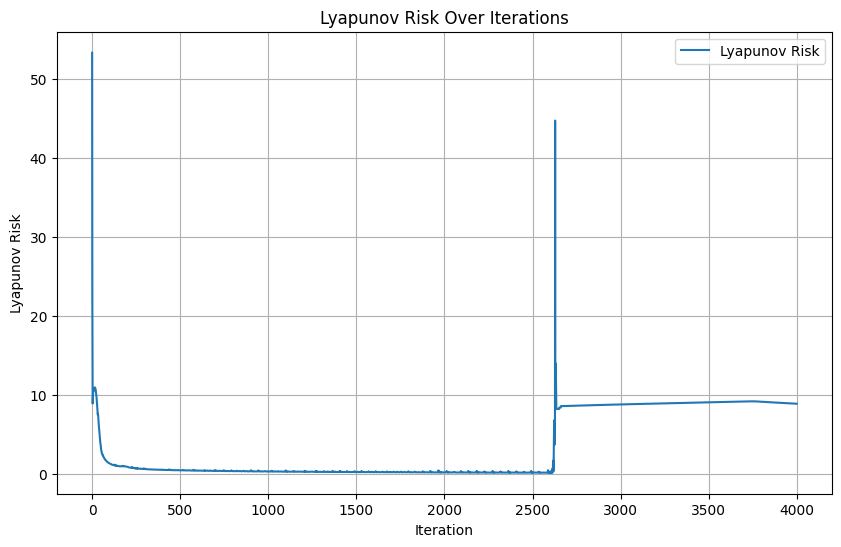

In [12]:
# After the training loop, plot the lyapunov risk.

plt.figure(figsize=(10, 6))
plt.plot(risk, label="Lyapunov Risk")
plt.xlabel("Iteration")
plt.ylabel("Lyapunov Risk")
plt.title("Lyapunov Risk Over Iterations")
plt.legend()
plt.grid()
plt.show()

In [13]:
# # we wish to plot the region of violations on grid size X grid size
grid_size = 100
x1 = np.linspace(-6, 6, grid_size)
x2 = np.linspace(-6, 6, grid_size)
X1, X2 = np.meshgrid(x1, x2)
grid_points = np.c_[X1.ravel(), X2.ravel()]

# # Compute the value of the Lie derivative at each grid point
def lie_derivative(x,model):
    ret_val = []
    x = torch.tensor(x,dtype=torch.float32)
    V_candidate, u = model(x)
    f = f_value(x,u)
    L_V = torch.diagonal(torch.mm(torch.mm(torch.mm(dtanh(V_candidate),model.layer2.weight)\
                            *dtanh(torch.tanh(torch.mm(x,model.layer1.weight.t())+model.layer1.bias)),model.layer1.weight),f.t()),0)
    return L_V

L_V = lie_derivative(grid_points,model)
# rescale the lie derivative to -1, 1 for lie derivative<0 and lie derivative>0 respectively
L_V = torch.where(L_V >= 0, 1, -1)
L_V_grid = L_V.detach().cpu().numpy().reshape(grid_size, grid_size)

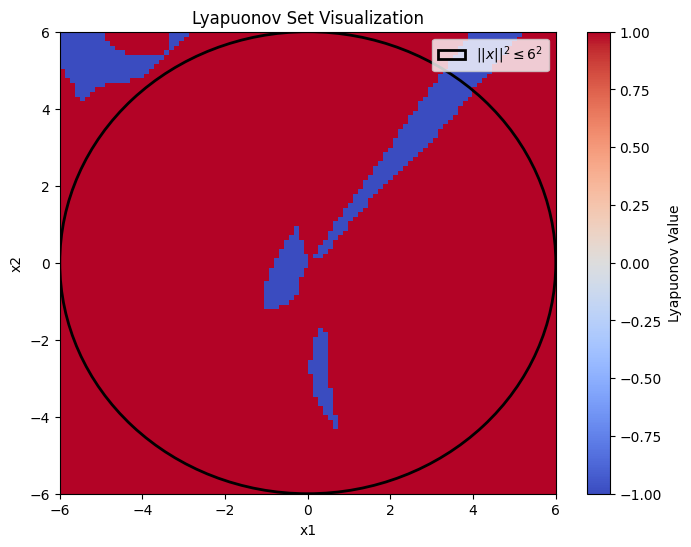

In [14]:
import matplotlib.patches as patches

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(
    L_V_grid,
    extent=[-6, 6, -6, 6],
    origin='lower',
    cmap='coolwarm',
    aspect='auto'
)
plt.colorbar(label="Lyapuonov Value")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Lyapuonov Set Visualization")

# Add a circle to the plot
circle = patches.Circle((0, 0), 6, color='black', fill=False, linewidth=2, label="$||x||^2 \leq 6^2$")
plt.gca().add_patch(circle)

# Add legend for the circle
plt.legend(loc='upper right')

plt.grid(False)
plt.show()

In [15]:
# Count the total number of values in the divergence set
total_values = L_V_grid.size

# Count the number of negative values
negative_values_count = (L_V_grid > 0).sum()

# Calculate the percentage of negative values
percentage_negative = negative_values_count 

print(f"The percentage of negative values in divergence_values_reshaped is {percentage_negative:.2f}")

# # PRINT the negative values taken by the divergence
# negative_values = divergence_values_reshaped[divergence_values_reshaped < 0]
# print(f"The negative values in divergence_values_reshaped are {negative_values}")

The percentage of negative values in divergence_values_reshaped is 9342.00
